In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
%cd drive/MyDrive/DATA

[Errno 2] No such file or directory: 'drive/MyDrive/DATA'
/content/drive/MyDrive/DATA


In [22]:
!pip install --quiet pandas scikit-learn tqdm sentence-transformers python-Levenshtein rapidfuzz

In [23]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Пути
INPUT_CSV = "frccsc_processed.csv"
OUTPUT_DIR = "path_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Параметры
K_MIN = 2
K_MAX = 200
SIL_STEP = 1
RANDOM_STATE = 42
MW=1.0
EMBED_DIM = 10
mode = 1


In [24]:
df = pd.read_csv(INPUT_CSV)
print("Загружено строк:", len(df))

if "WorkDir" not in df.columns:
    raise ValueError("Входной CSV должен содержать столбец WorkDir")

paths_full = df["WorkDir"].fillna("").astype(str)

# получаем уникальные пути
unique_paths_df = df[["WorkDir"]].drop_duplicates().reset_index(drop=False)
# index — это исходная позиция (нам она пригодится)
unique_paths_df.rename(columns={"index": "OrigIndex"}, inplace=True)

unique_paths_df["WorkDir"] = unique_paths_df["WorkDir"].astype(str)

if mode == 1:
    paths = unique_paths_df["WorkDir"]
else:
    paths = paths_full


Загружено строк: 13460


In [25]:
def find_best_k_by_silhouette(X, k_min=K_MIN, k_max=K_MAX, step=SIL_STEP):
    best_k = None
    best_score = -1.0
    n = X.shape[0]
    k_upper = min(k_max, max(2, n - 1))

    for k in range(k_min, k_upper + 1, step):
        if k >= n:
            break
        try:
            km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = km.fit_predict(X)

            if len(np.unique(labels)) <= 1:
                continue

            score = silhouette_score(X, labels)

            if score > best_score:
                best_score = score
                best_k = k
        except:
            continue

    if best_k is None:
        best_k = 2
        best_score = -1.0

    return best_k, best_score


In [26]:
def propagate_labels_to_full_df(df_full, unique_paths_df, labels_unique):
    """
    df_full — исходный DataFrame
    unique_paths_df — таблица уникальных путей с колонкой OrigIndex
    labels_unique — метки кластеров для уникальных WorkDir
    """

    # создаём таблицу WorkDir → ClusterID
    unique_paths_df["ClusterID"] = labels_unique
    cluster_map = dict(zip(unique_paths_df["WorkDir"], unique_paths_df["ClusterID"]))

    # распространение меток на весь DataFrame
    df_full["PathClusterID"] = df_full["WorkDir"].map(cluster_map)

    return df_full


In [27]:
def vectorize_paths_token_label(paths_series):
    tokens = paths_series.apply(lambda x: x.strip("/").split("/")[1:])
    max_len = max(tokens.map(len))

    # Собираем токены по позициям
    tokens_by_pos = [[] for _ in range(max_len)]
    for path in tokens:
        for i, tok in enumerate(path):
            tokens_by_pos[i].append(tok)

    for i in range(max_len):
        tokens_by_pos[i].sort()

    position_encoders = []
    for pos_list in tokens_by_pos:
        le = LabelEncoder()
        le.fit(pos_list)
        position_encoders.append(le)

    vectors = []
    for path in tokens:
        enc = []
        for i in range(max_len):
            if i < len(path):
                tok = path[i]
                enc.append(position_encoders[i].transform([tok])[0])
            else:
                enc.append(-1)
        vectors.append(enc)

    return np.array(vectors)


In [28]:
print("[1] Простая структурная кластеризация")

X_struct = vectorize_paths_token_label(paths)

# Поиск оптимального k
best_k_struct, _ = find_best_k_by_silhouette(X_struct)

km_struct = KMeans(n_clusters=best_k_struct, random_state=RANDOM_STATE, n_init=10)
labels_struct = km_struct.fit_predict(X_struct)

if mode == 1:
    df_struct = propagate_labels_to_full_df(df.copy(), unique_paths_df.copy(), labels_struct)
else:
    df_struct = df.copy()
    df_struct["PathClusterID"] = labels_struct

output_struct = os.path.join(OUTPUT_DIR, "frccsc_processed_struct.csv")
df_struct.to_csv(output_struct, index=False)

print("Файл сохранён:", output_struct)


[1] Простая структурная кластеризация
Файл сохранён: path_processed/frccsc_processed_struct.csv


In [29]:
# Импорты для PREP
from collections import defaultdict
import Levenshtein

def ld(a, b):
    return Levenshtein.distance(a, b)

In [30]:
def compute_weights(n_parts, MW=MW):
    if n_parts <= 1:
        return [MW]
    denom = n_parts - 1
    return [MW - (i) * ((MW - 1.0) / denom) for i in range(n_parts)]


In [31]:
def weighted_path_distance(parts_a, parts_b, MW=MW):
    """
    Считает расстояние между двумя путями:
    sum_i [ LD(a_i, b_i) * weight_i ]
    """
    la = len(parts_a)
    lb = len(parts_b)
    n = max(la, lb)

    if n == 0:
        return 0.0

    weights = compute_weights(n, MW=MW)
    s = 0.0

    for i in range(n):
        a_i = parts_a[i] if i < la else ""
        b_i = parts_b[i] if i < lb else ""
        d = ld(a_i, b_i)
        s += d * weights[i]

    return float(s)


In [32]:
def build_distance_matrix(parts_list, MW=MW, show_progress=False):
    """
    Создаёт матрицу расстояний (n × n) для списка путей одного пользователя.
    """
    n = len(parts_list)
    D = np.zeros((n, n), dtype=float)

    rng = tqdm(range(n), desc="pairwise") if show_progress else range(n)

    for i in rng:
        for j in range(i + 1, n):
            d = weighted_path_distance(parts_list[i], parts_list[j], MW=MW)
            D[i, j] = d
            D[j, i] = d

    return D


In [33]:
def mds_embed_from_D(D, n_components=EMBED_DIM):
    from sklearn.manifold import MDS

    n = D.shape[0]
    n_comp = min(n_components, max(1, n - 1))

    mds = MDS(
        n_components=n_comp,
        dissimilarity="precomputed",
        random_state=RANDOM_STATE,
        n_init=1,
        max_iter=300
    )

    return mds.fit_transform(D)


In [34]:
print("[2] Реализация PREP")

parts_list = [p.strip("/").split("/")[1:] for p in paths]

D = build_distance_matrix(parts_list, MW=MW)
X = mds_embed_from_D(D)

best_k, _ = find_best_k_by_silhouette(X)

km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_prep = km.fit_predict(X)

if mode == 1:
    df_prep = propagate_labels_to_full_df(df.copy(), unique_paths_df.copy(), labels_prep)
else:
    df_prep = df.copy()
    df_prep["PathClusterID"] = labels_prep

output_prep = os.path.join(OUTPUT_DIR, "frccsc_processed_prep.csv")
df_prep.to_csv(output_prep, index=False)

print("Файл сохранён:", output_prep)



[2] Реализация PREP
Файл сохранён: path_processed/frccsc_processed_prep.csv


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans

print("[3] BERT-кластеризация")

MODEL_NAME = "all-MiniLM-L6-v2"

model = SentenceTransformer(MODEL_NAME)

# Преобразуем пути в эмбеддинги
paths_list = paths.fillna("").astype(str).tolist()
print(f"Encoding {len(paths_list)} paths with {MODEL_NAME} ...")
embeddings = model.encode(paths_list, show_progress_bar=True, batch_size=64)
X_bert = np.array(embeddings)
print("Encoding finished. Embedding shape:", X_bert.shape)

# Подбор оптимального числа кластеров методом силуэта
best_k_bert, _ = find_best_k_by_silhouette(X_bert)


# Финальная кластеризация
km_bert = KMeans(n_clusters=best_k_bert, random_state=RANDOM_STATE, n_init=10)
labels_bert = km_bert.fit_predict(X_bert)

# Сохранение результата
if mode == 1:
    df_bert = propagate_labels_to_full_df(df.copy(), unique_paths_df.copy(), labels_bert)
else:
    df_bert = df.copy()
    df_bert["PathClusterID"] = labels_bert

output_bert = os.path.join(OUTPUT_DIR, "frccsc_processed_bert.csv")
df_bert.to_csv(output_bert, index=False)

print("Файл сохранён:", output_bert)

[3] BERT-кластеризация


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 1539 paths with all-MiniLM-L6-v2 ...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Encoding finished. Embedding shape: (1539, 384)


In [36]:
# ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ПО ВРЕМЕНИ ВЫПОЛНЕНИЯ
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score, silhouette_score, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway, kruskal

INPUT_DIR = "path_processed"

FILES = {
    "Struct": os.path.join(INPUT_DIR, "frccsc_processed_struct.csv"),
    "PREP": os.path.join(INPUT_DIR, "frccsc_processed_prep.csv"),
    "BERT": os.path.join(INPUT_DIR, "frccsc_processed_bert.csv"),
}

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

N_BOOTSTRAP = 50
SAMPLE_FRAC = 0.7
RANDOM_STATE = 42
N_BINS_MI = 10

rng = np.random.default_rng(RANDOM_STATE)


def compute_cluster_stats(df, time_col=TIME_COL, cluster_col=CLUSTER_COL):
    tmp = df[[cluster_col, time_col]].dropna()
    grouped = tmp.groupby(cluster_col)[time_col]

    stats = grouped.agg(["count", "mean", "std", "var", "min", "max"]).rename(
        columns={
            "count": "size",
            "mean": "mean_time",
            "std": "std_time",
            "var": "var_time",
            "min": "min_time",
            "max": "max_time",
        }
    )
    stats["cv_time"] = stats["std_time"] / stats["mean_time"].replace(0, np.nan)
    return stats.reset_index()


def compute_global_metrics(df, time_col=TIME_COL, cluster_col=CLUSTER_COL, n_bins_mi=N_BINS_MI):
    df = df[[time_col, cluster_col]].dropna().copy()
    if df.empty:
        return None, None

    y = df[time_col].values.astype(float)
    labels = df[cluster_col].values
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    cl_stats = compute_cluster_stats(df, time_col, cluster_col)
    mean_intra_var = cl_stats["var_time"].mean()
    weights = cl_stats["size"].values
    weighted_mean_intra_var = np.average(cl_stats["var_time"].fillna(0).values, weights=weights)

    X_time = y.reshape(-1, 1)
    silhouette_time = None
    if n_clusters > 1 and len(df) > n_clusters:
        try:
            silhouette_time = silhouette_score(X_time, labels)
        except Exception:
            silhouette_time = None

    groups = [df.loc[df[cluster_col] == c, time_col].values for c in unique_clusters]
    anova_F, anova_p = None, None
    try:
        anova_F, anova_p = f_oneway(*groups)
    except Exception:
        pass

    kruskal_H, kruskal_p = None, None
    try:
        kruskal_H, kruskal_p = kruskal(*groups)
    except Exception:
        pass

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_clusters = encoder.fit_transform(labels.reshape(-1, 1))

    reg = LinearRegression()
    try:
        reg.fit(X_clusters, y)
        y_pred = reg.predict(X_clusters)
        r2 = r2_score(y, y_pred)
    except Exception:
        r2 = None

    mi = None
    try:
        df["time_bin"] = pd.qcut(df[time_col], q=n_bins_mi, duplicates="drop")
        time_bins = df["time_bin"].cat.codes.values
        mi = mutual_info_score(labels, time_bins)
    except Exception:
        mi = None

    metrics = {
        "n_clusters": n_clusters,
        "mean_intra_var": mean_intra_var,
        "weighted_mean_intra_var": weighted_mean_intra_var,
        "silhouette_time": silhouette_time,
        "anova_F": anova_F,
        "anova_p": anova_p,
        "kruskal_H": kruskal_H,
        "kruskal_p": kruskal_p,
        "r2_cluster_time": r2,
        "mutual_info_cluster_time": mi,
    }
    return metrics, cl_stats


def bootstrap_metrics(df, n_bootstrap=N_BOOTSTRAP, sample_frac=SAMPLE_FRAC, random_state=None):
    rng_local = np.random.default_rng(random_state) if random_state is not None else np.random.default_rng()
    metrics_list = []
    n = len(df)
    if n == 0:
        return metrics_list

    for _ in range(n_bootstrap):
        idx = rng_local.choice(n, size=max(2, int(n * sample_frac)), replace=False)
        df_sample = df.iloc[idx].copy()
        m, _ = compute_global_metrics(df_sample)
        if m is not None:
            metrics_list.append(m)
    return metrics_list


def summarize_bootstrap(metrics_list, metric_name):
    values = [m[metric_name] for m in metrics_list if m.get(metric_name) is not None]
    if not values:
        return None, None, None
    values = np.array(values, dtype=float)
    return np.mean(values), np.percentile(values, 2.5), np.percentile(values, 97.5)


all_results = {}
cluster_stats_by_method = {}

for method_name, filepath in FILES.items():
    if not os.path.exists(filepath):
        print(f"[!] Файл не найден для метода {method_name}: {filepath}")
        continue

    print(f"\n=== Оценка метода: {method_name} ===")
    df_method = pd.read_csv(filepath)

    if TIME_COL not in df_method.columns or CLUSTER_COL not in df_method.columns:
        print(f"[!] В файле {filepath} нет столбцов {TIME_COL} или {CLUSTER_COL}")
        continue

    df_valid = df_method[[TIME_COL, CLUSTER_COL]].dropna()
    df_valid = df_valid[df_valid[CLUSTER_COL] != -1]

    if df_valid.empty:
        print(f"[!] Нет валидных строк для метода {method_name}")
        continue

    metrics, cl_stats = compute_global_metrics(df_valid)
    all_results[method_name] = {"metrics": metrics}
    cluster_stats_by_method[method_name] = cl_stats

    print("Глобальные метрики:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    print("  Бутстрап-оценка метрик...")
    bs_metrics_list = bootstrap_metrics(df_valid, random_state=RANDOM_STATE)
    all_results[method_name]["bootstrap"] = bs_metrics_list

    for mname in ["mean_intra_var", "weighted_mean_intra_var", "r2_cluster_time", "mutual_info_cluster_time"]:
        mean_b, low_b, high_b = summarize_bootstrap(bs_metrics_list, mname)
        print(f"  {mname} (bootstrap): mean={mean_b}, 95% CI=({low_b}, {high_b})")

rows = []
for method_name, res in all_results.items():
    m = res["metrics"]
    rows.append({
        "Method": method_name,
        "n_clusters": m["n_clusters"],
        "mean_intra_var": m["mean_intra_var"],
        "weighted_mean_intra_var": m["weighted_mean_intra_var"],
        "silhouette_time": m["silhouette_time"],
        "anova_F": m["anova_F"],
        "anova_p": m["anova_p"],
        "kruskal_H": m["kruskal_H"],
        "kruskal_p": m["kruskal_p"],
        "r2_cluster_time": m["r2_cluster_time"],
        "mutual_info_cluster_time": m["mutual_info_cluster_time"],
    })

summary_df = pd.DataFrame(rows)
print("\n=== Сводная таблица по методам ===")
print(summary_df.to_string(index=False))


=== Оценка метода: Struct ===
Глобальные метрики:
  n_clusters: 197
  mean_intra_var: 39811395553.186035
  weighted_mean_intra_var: 6155870620.576344
  silhouette_time: -0.8968132419425807
  anova_F: 34.69296606738017
  anova_p: 0.0
  kruskal_H: 3703.5118772434544
  kruskal_p: 0.0
  r2_cluster_time: 0.33892647653344343
  mutual_info_cluster_time: 0.3780384456401794
  Бутстрап-оценка метрик...
  mean_intra_var (bootstrap): mean=35277849870.319954, 95% CI=(13703560451.079088, 69288202099.57967)
  weighted_mean_intra_var (bootstrap): mean=6059737910.72669, 95% CI=(4715507408.902564, 7269304273.182201)
  r2_cluster_time (bootstrap): mean=0.3643040817648431, 95% CI=(0.2505335034841343, 0.47872250684212936)
  mutual_info_cluster_time (bootstrap): mean=0.39288869085308226, 95% CI=(0.38548829579195126, 0.4031758960134545)

=== Оценка метода: PREP ===
Глобальные метрики:
  n_clusters: 114
  mean_intra_var: 14672730799.077822
  weighted_mean_intra_var: 7302005563.469781
  silhouette_time: -0.89

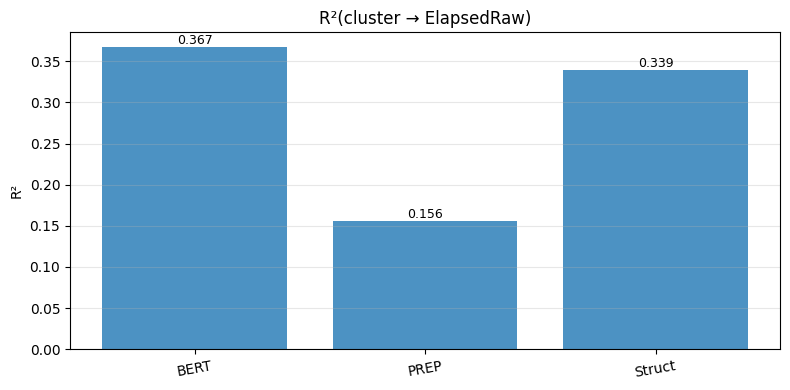

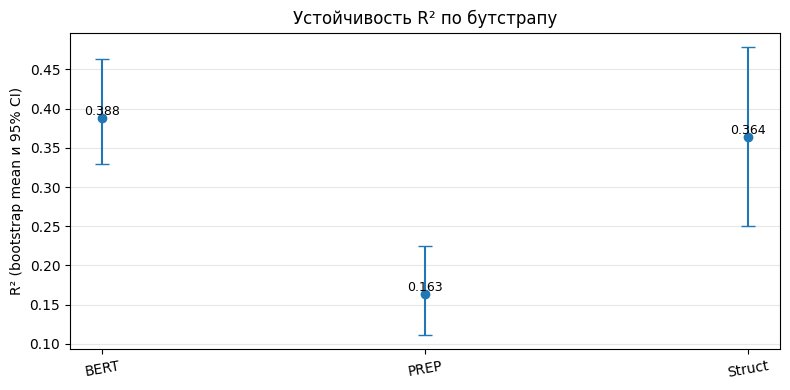

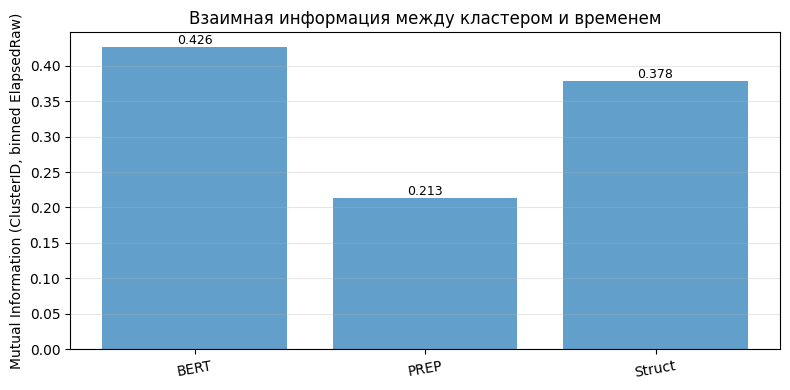

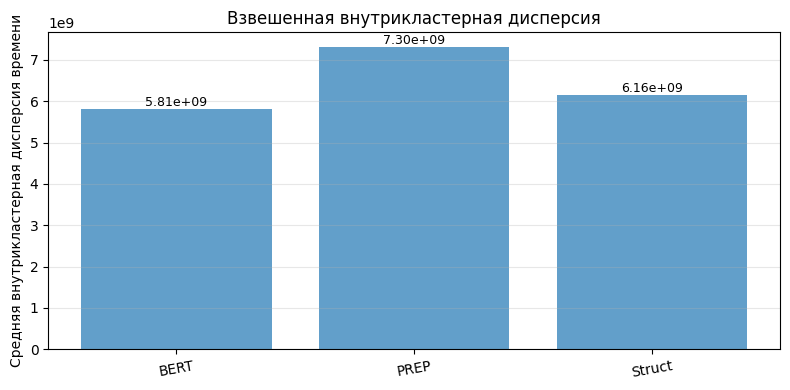

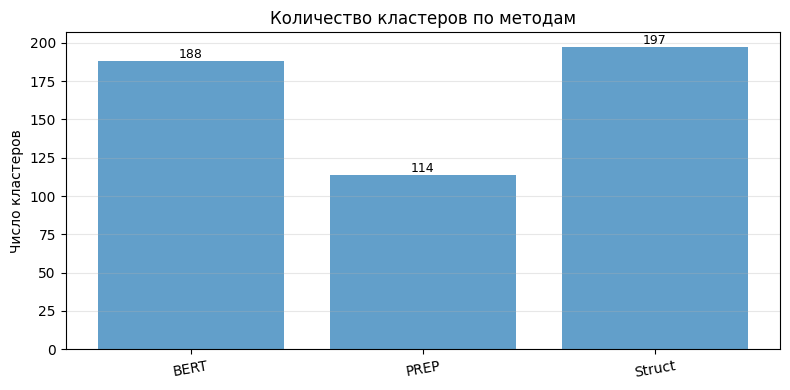

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = summary_df.copy()
plot_df = plot_df.sort_values("Method").reset_index(drop=True)

r2_mean_bs, r2_low_bs, r2_high_bs = [], [], []
mi_mean_bs, mi_low_bs, mi_high_bs = [], [], []

for method in plot_df["Method"]:
    bs = all_results[method]["bootstrap"]

    mean_b, low_b, high_b = summarize_bootstrap(bs, "r2_cluster_time")
    r2_mean_bs.append(mean_b)
    r2_low_bs.append(low_b)
    r2_high_bs.append(high_b)

    mean_b, low_b, high_b = summarize_bootstrap(bs, "mutual_info_cluster_time")
    mi_mean_bs.append(mean_b)
    mi_low_bs.append(low_b)
    mi_high_bs.append(high_b)

plot_df["r2_mean_bs"] = r2_mean_bs
plot_df["r2_low_bs"] = r2_low_bs
plot_df["r2_high_bs"] = r2_high_bs
plot_df["mi_mean_bs"] = mi_mean_bs
plot_df["mi_low_bs"] = mi_low_bs
plot_df["mi_high_bs"] = mi_high_bs

x = np.arange(len(plot_df))
labels = plot_df["Method"].tolist()

# --- График 1: R^2 по методам ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["r2_cluster_time"], alpha=0.8)
plt.xticks(x, labels, rotation=10)
plt.ylabel("R²")
plt.title("R²(cluster → ElapsedRaw)")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["r2_cluster_time"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 2: R^2 с доверительными интервалами (бутстрап) ---
plt.figure(figsize=(8, 4))
err_low = np.array(plot_df["r2_mean_bs"]) - np.array(plot_df["r2_low_bs"])
err_high = np.array(plot_df["r2_high_bs"]) - np.array(plot_df["r2_mean_bs"])
yerr = np.vstack([err_low, err_high])
plt.errorbar(x, plot_df["r2_mean_bs"], yerr=yerr, fmt="o", capsize=5)
plt.xticks(x, labels, rotation=10)
plt.ylabel("R² (bootstrap mean и 95% CI)")
plt.title("Устойчивость R² по бутстрапу")
plt.grid(axis="y", alpha=0.3)
for xi, v in zip(x, plot_df["r2_mean_bs"]):
    plt.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 3: Mutual Information ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["mutual_info_cluster_time"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Mutual Information (ClusterID, binned ElapsedRaw)")
plt.title("Взаимная информация между кластером и временем")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["mutual_info_cluster_time"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 4: Средняя внутрикластерная дисперсия ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["weighted_mean_intra_var"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Средняя внутрикластерная дисперсия времени")
plt.title("Взвешенная внутрикластерная дисперсия")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["weighted_mean_intra_var"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 5: Число кластеров ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["n_clusters"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Число кластеров")
plt.title("Количество кластеров по методам")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["n_clusters"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

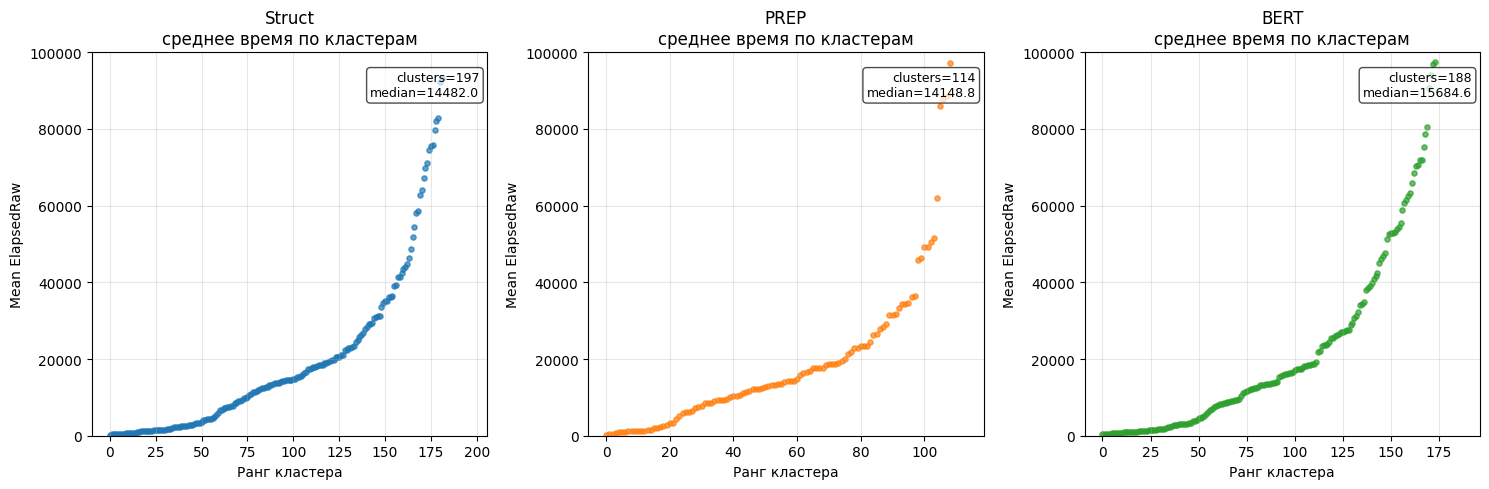

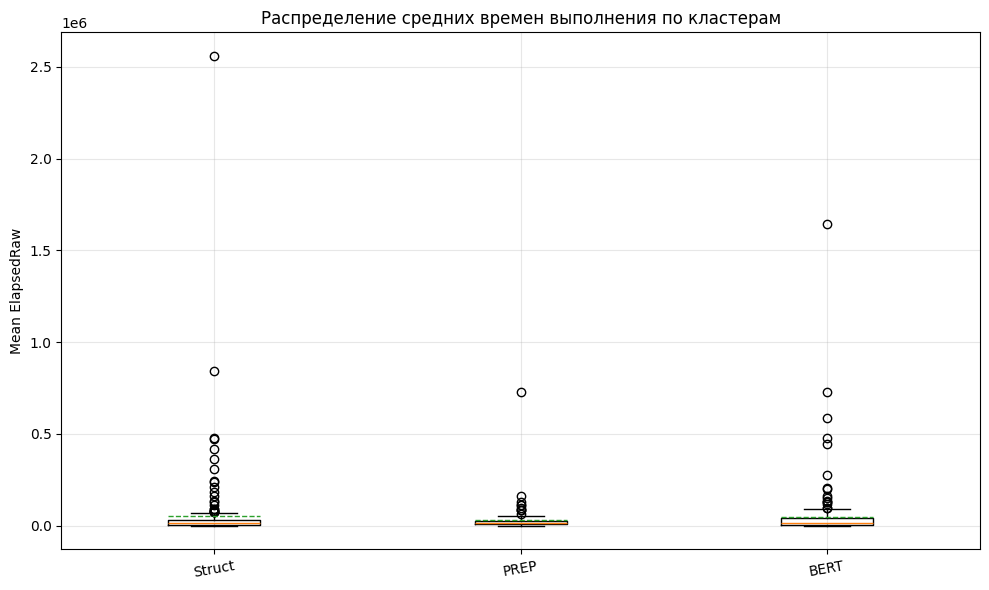

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

INPUT_DIR = "path_processed"
FILES = {
    "Struct": os.path.join(INPUT_DIR, "frccsc_processed_struct.csv"),
    "PREP": os.path.join(INPUT_DIR, "frccsc_processed_prep.csv"),
    "BERT": os.path.join(INPUT_DIR, "frccsc_processed_bert.csv"),
}

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

colors = {
    "Struct": "tab:blue",
    "PREP": "tab:orange",
    "BERT": "tab:green"
}

# === График 1: среднее время выполнения в каждом кластере (ранжирование по возрастанию) ===
plt.figure(figsize=(15, 5))
Y_MAX = 100000

for idx, (name, filepath) in enumerate(FILES.items(), start=1):
    df_local = pd.read_csv(filepath)
    df_local = df_local[[CLUSTER_COL, TIME_COL]].dropna()
    cl_stats = df_local.groupby(CLUSTER_COL)[TIME_COL].mean().reset_index()
    cl_stats = cl_stats.sort_values(TIME_COL).reset_index(drop=True)
    cl_stats["Rank"] = cl_stats.index

    plt.subplot(1, 3, idx)
    plt.scatter(cl_stats["Rank"], cl_stats[TIME_COL], s=14, alpha=0.7, color=colors[name])
    plt.title(f"{name}\nсреднее время по кластерам")
    plt.xlabel("Ранг кластера")
    plt.ylabel("Mean ElapsedRaw")
    plt.ylim(0, Y_MAX)
    plt.grid(alpha=0.3)

    if len(cl_stats) > 0:
        plt.text(
            0.98, 0.95,
            f"clusters={len(cl_stats)}\nmedian={cl_stats[TIME_COL].median():.1f}",
            transform=plt.gca().transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )

plt.tight_layout()
plt.show()

# === График 2: распределение средних значений по кластерам ===
plt.figure(figsize=(10, 6))
data_for_boxplot = []
box_labels = []

for name, filepath in FILES.items():
    df_local = pd.read_csv(filepath)
    df_local = df_local[[CLUSTER_COL, TIME_COL]].dropna()
    cl_stats = df_local.groupby(CLUSTER_COL)[TIME_COL].mean()
    data_for_boxplot.append(cl_stats.values)
    box_labels.append(name)

plt.boxplot(data_for_boxplot, labels=box_labels, showmeans=True, meanline=True)
plt.title("Распределение средних времен выполнения по кластерам")
plt.ylabel("Mean ElapsedRaw")
plt.grid(alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()